# Event Exploration (System)

Parsing the data and understanding it (EventData attribute)

In [27]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from anomaly_detection.etl.load import load_records, load_eventdata_df, load_eventdata
from anomaly_detection.utils.profile_eventdata import profile_all, print_summary, summarize_constants, export_profiles_csv

plt.style.use('ggplot')

In [28]:
# Path to the data
project_folder = Path.cwd().parent

output_path = project_folder / "data/event_exploration/system"

evtx_path = project_folder / "data/raw/93_syslog.evtx"

evtx_path

WindowsPath('c:/Users/hp/Documents/School/anomaly-detection/data/raw/93_syslog.evtx')

In [29]:
records = load_records(evtx_path)

len(records)

59779

In [30]:
with open(project_folder / "data/processed/record.txt", "w", encoding="utf-8") as file:
    file.write(json.dumps(
        records[0],
        indent=4
    ))

records[0]

{'#attributes': {'xmlns': 'http://schemas.microsoft.com/win/2004/08/events/event'},
 'System': {'Provider': {'Name': 'Service Control Manager',
   'Guid': '{555908d1-a6d7-4695-8e1e-26931d2012f4}',
   'EventSourceName': 'Service Control Manager'},
  'EventID': {'#attributes': {'Qualifiers': 16384}, '#text': 7036},
  'Version': 0,
  'Level': 4,
  'Task': 0,
  'Opcode': 0,
  'Keywords': '0x8080000000000000',
  'TimeCreated': {'SystemTime': '2026-03-13T04:58:47.068108Z'},
  'EventRecordID': 210478,
  'Correlation': None,
  'Execution': {'ProcessID': 932, 'ThreadID': 5368},
  'Channel': 'System',
  'Computer': 'ESANTE.carte.com.tn',
  'Security': None},
 'EventData': {'param1': 'Service de transfert intelligent en arrière-plan',
  'param2': 'en cours d’exécution',
  'Binary': '42004900540053002F0034000000'}}

In [31]:
event_df = load_eventdata_df(evtx_path)

event_df.head()

,EventID,EventRecordID,TimeCreated,PayloadSource,NewTime,OldTime,Reason,ProcessName,ProcessID,VersionLen,...,AdapterSuffixName,DnsServerList,Sent UpdateServer,Ipaddress,DeviceObject,Url,Default SD String:,MinimumPasswordLength,MinimumPasswordLengthAudit,DwordVal
0,1,212844,2026-03-17T16:54:26.905165Z,EventData,2026-03-17T16:54:26.904000Z,2026-03-17T16:54:21.796975Z,1.0,\Device\HarddiskVolume4\Windows\System32\svcho...,1720.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,212845,2026-03-17T16:55:32.379127Z,EventData,2026-03-17T16:55:32.378000Z,2026-03-17T16:55:26.990171Z,1.0,\Device\HarddiskVolume4\Windows\System32\svcho...,1720.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,212846,2026-03-17T16:56:37.849153Z,EventData,2026-03-17T16:56:37.848000Z,2026-03-17T16:56:32.456317Z,1.0,\Device\HarddiskVolume4\Windows\System32\svcho...,1720.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,212847,2026-03-17T16:57:43.301179Z,EventData,2026-03-17T16:57:43.300000Z,2026-03-17T16:57:37.900402Z,1.0,\Device\HarddiskVolume4\Windows\System32\svcho...,1720.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,212848,2026-03-17T16:58:48.783117Z,EventData,2026-03-17T16:58:48.782000Z,2026-03-17T16:58:43.381555Z,1.0,\Device\HarddiskVolume4\Windows\System32\svcho...,1720.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
event_df.columns

Index(['EventID', 'EventRecordID', 'TimeCreated', 'PayloadSource', 'NewTime',
       'OldTime', 'Reason', 'ProcessName', 'ProcessID', 'VersionLen',
       ...
       'AdapterSuffixName', 'DnsServerList', 'Sent UpdateServer', 'Ipaddress',
       'DeviceObject', 'Url', 'Default SD String:', 'MinimumPasswordLength',
       'MinimumPasswordLengthAudit', 'DwordVal'],
      dtype='str', length=123)

In [33]:
counts = event_df["EventID"].value_counts()

min_frequency = 250

frequent = counts[counts >= min_frequency]
others = counts[counts < min_frequency]

In [40]:
event_descriptions = {
    7040: "Service startup changed",
    7036: "Service state changed",
}

frequent.index = [
    f"{eid}: {event_descriptions.get(eid, 'Unknown')}"
    if isinstance(eid, int) else eid
    for eid in frequent.index
]

other_label = f""
frequent[other_label] = others.sum()

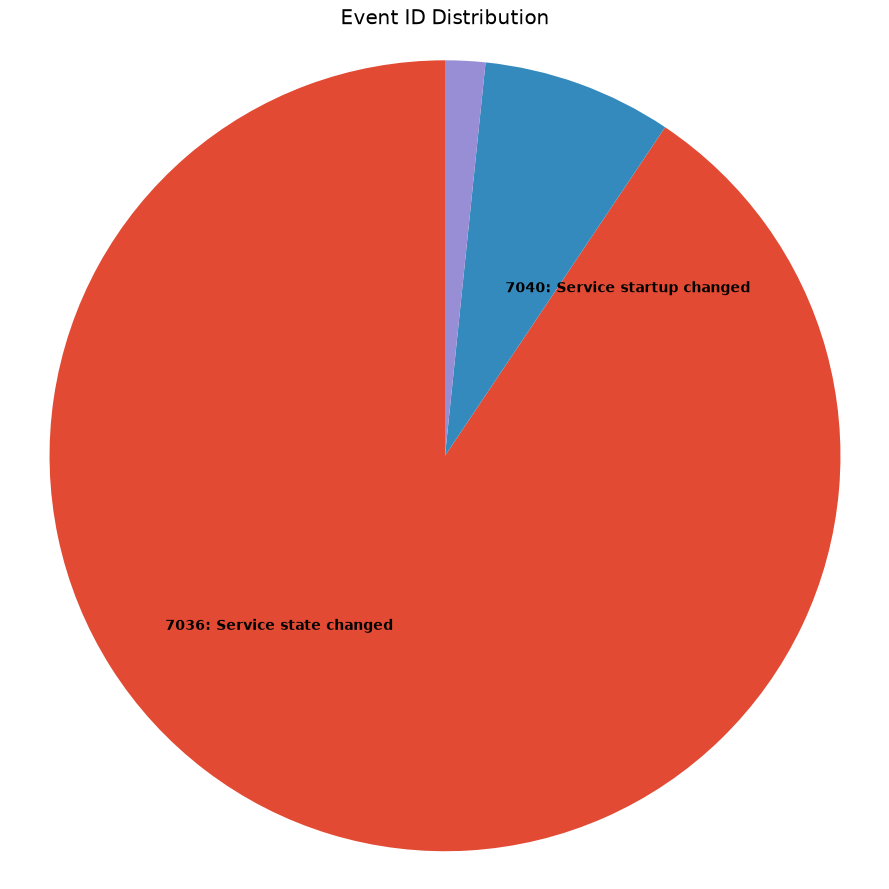

In [43]:
fig, ax = plt.subplots(figsize=(9, 9))

wedges, label_texts = ax.pie(
    frequent.values,
    labels=frequent.index,
    startangle=90,
    labeldistance=0.45,
)

# Make EventIDs bold
for t in label_texts:
    t.set_fontweight("bold")
    t.set_fontsize(10)

ax.set_title("Event ID Distribution")
ax.axis("equal")
plt.tight_layout()

plt.savefig(output_path / "event_id_distribution.png")

plt.show()

In [36]:
event_dfs = load_eventdata(evtx_path)

In [37]:
profiles = profile_all(event_dfs)

export_profiles_csv(profiles, output_path)

In [38]:
from contextlib import redirect_stdout

with open(output_path / 'profile_summary.txt', 'w') as f:
    with redirect_stdout(f):
        print_summary(profiles, event_dfs)

print_summary(profiles, event_dfs)


EventID 1 (35 records)
  constant  : -
  >=95% null: -
  variable  : ['NewTime', 'OldTime', 'Reason', 'ProcessName', 'ProcessID', 'VersionLen', 'Version', 'Status', 'FinalStatus', 'DeviceVersionMajor', 'DeviceVersionMinor', 'DeviceNameLength', 'DeviceName', 'DeviceTime']

EventID 2 (12 records)
  constant  : ['VersionLen', 'Status']
  >=95% null: -
  variable  : ['Version']

EventID 3 (6 records)
  constant  : ['MiniportNameLen', 'MiniportName']
  >=95% null: -
  variable  : -

EventID 6 (61 records)
  constant  : ['FinalStatus']
  >=95% null: -
  variable  : ['DeviceVersionMajor', 'DeviceVersionMinor', 'DeviceNameLength', 'DeviceName', 'DeviceTime']

EventID 11 (6 records)
  constant  : ['MiniportNameLen', 'MiniportName']
  >=95% null: -
  variable  : -

EventID 12 (21 records)
  constant  : -
  >=95% null: -
  variable  : ['MiniportNameLen', 'MiniportName', 'MajorVersion', 'MinorVersion', 'BuildVersion', 'QfeVersion', 'ServiceVersion', 'BootMode', 'StartTime']

EventID 13 (9 records

In [39]:
constants = summarize_constants(profiles, event_dfs)

clean_constants = {int(k): v for k, v in constants.items()}

with open(output_path / 'constants.txt', 'w') as f:
    f.write(json.dumps(clean_constants, indent=4, default=int))

clean_constants

{1: {},
 2: {'VersionLen': np.int64(3), 'Status': np.int64(3221225473)},
 3: {'MiniportNameLen': np.int64(37),
  'MiniportName': 'Carte réseau de bus Microsoft Hyper-V'},
 6: {'FinalStatus': '0x0'},
 11: {'MiniportNameLen': np.int64(37),
  'MiniportName': 'Carte réseau de bus Microsoft Hyper-V'},
 12: {},
 13: {},
 14: {},
 15: {},
 16: {},
 18: {'EntryCount': np.int64(1)},
 19: {},
 20: {},
 25: {'BootMenuPolicy': np.int64(0)},
 27: {'BootType': np.int64(0), 'LoadOptions': ' NOEXECUTE=OPTOUT  NOVGA'},
 30: {'ResetEndStart': np.int64(0)},
 32: {'BitlockerUserInputTime': np.int64(0)},
 35: {'#attributes.Name': 'TMP_EVENT_TIME_SOURCE_CHOSEN'},
 36: {'UnsynchronizedTimeSeconds': np.int64(49152),
  'TimeRemainingToSetLocalClockFreeRunningSeconds': np.int64(0),
  '#attributes.Name': 'TMP_EVENT_TIME_SOURCE_NONE'},
 43: {},
 44: {},
 55: {'Group': np.int64(0),
  'IdleStateCount': np.int64(1),
  'IdleImplementation': np.int64(1),
  'NominalFrequency': np.int64(2100),
  'MaximumPerformancePerce